# GoogleNet (Inception v1)
# Dataset: CIFAR-10

In [66]:
!pip install mlflow --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.cuda.amp import GradScaler, autocast
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import mlflow
import mlflow.pytorch
import warnings
warnings.filterwarnings('ignore')
from torch.utils.data import Subset



* Random seeds for reproducibility

In [67]:
torch.manual_seed(42)
np.random.seed(42)

## Data Augmentation


*   Resizing
*   Rotation
*   Flip
*   Jitter



In [68]:
# Step 1: Enhanced Data Loading with Validation Split (80/10/10)
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [69]:
# Load datasets
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_val_test)

## Reduce size of dataset to 1000.

In [70]:
# Reduce train+val dataset to 10k images
reduced_size = 10000
indices = list(range(len(full_train_dataset)))[:reduced_size]
reduced_dataset = Subset(full_train_dataset, indices)

In [71]:
train_size = int(0.8 * len(reduced_dataset))
val_size = len(reduced_dataset) - train_size
train_dataset, val_dataset = random_split(reduced_dataset, [train_size, val_size])

In [72]:
test_indices = list(range(2000))
test_dataset = Subset(test_dataset, test_indices)

In [73]:


print(f"Dataset splits:")
print(f"  Training:   {len(train_dataset):5d}")
print(f"  Validation: {len(val_dataset):5d}")
print(f"  Test:       {len(test_dataset):5d}")

Dataset splits:
  Training:    8000
  Validation:  2000
  Test:        2000


In [74]:
# DataLoaders with optimized settings
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

In [75]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## Step2: Model Setup

In [76]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = torchvision.models.googlenet(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)

Using device: cuda


In [77]:
# Freeze all except last few layers
for param in model.parameters():
    param.requires_grad = False
# for param in model.inception5b.parameters():
#     param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}, Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

Total params: 5,610,154, Trainable params: 10,250 (0.2%)


## Training Setup

In [78]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = GradScaler()

## Training with Validation

In [119]:
# Step 4: Training with Validation



# mlflow.set_experiment("GoogLeNet_CIFAR10")

num_epochs = 50
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = running_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [94]:
!pip install pyngrok --quiet
!pip install mlflow --quiet

In [84]:
mlflow.end_run()
mlflow.log_param("model_name", "GoogLeNet")
mlflow.log_param("pretrained", True)
mlflow.log_param("batch_size", 128)
mlflow.log_param("num_epochs", num_epochs)
mlflow.log_param("learning_rate", 0.001)
mlflow.log_param("weight_decay", 1e-4)
best_val_acc = 0.0
for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


   # Validation
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:2d}/{num_epochs}: "
          f"Train Loss: {train_loss:.4f} ({train_acc:.2f}%) | "
          f"Val Loss: {val_loss:.4f} ({val_acc:.2f}%)")
    mlflow.log_metric("train_loss", train_loss, step=epoch)
    mlflow.log_metric("val_loss", val_loss, step=epoch)
    mlflow.log_metric("train_acc", train_acc, step=epoch)
    mlflow.log_metric("val_acc", val_acc, step=epoch)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_googlenet_cifar10.pth')
        # print(f"Val Acc: {val_acc:.2f}%)")

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch  1/50: Train Loss: 2.0212 (36.62%) | Val Loss: 1.7120 (56.95%)
Epoch  2/50: Train Loss: 1.5931 (55.70%) | Val Loss: 1.4194 (63.75%)
Epoch  3/50: Train Loss: 1.3724 (61.64%) | Val Loss: 1.2633 (64.75%)
Epoch  4/50: Train Loss: 1.2359 (63.40%) | Val Loss: 1.1683 (65.35%)
Epoch  5/50: Train Loss: 1.1632 (64.53%) | Val Loss: 1.0962 (67.30%)
Epoch  6/50: Train Loss: 1.1128 (65.09%) | Val Loss: 1.0284 (70.30%)
Epoch  7/50: Train Loss: 1.0613 (66.64%) | Val Loss: 1.0039 (68.25%)
Epoch  8/50: Train Loss: 1.0473 (65.99%) | Val Loss: 0.9954 (68.90%)
Epoch  9/50: Train Loss: 1.0237 (67.21%) | Val Loss: 0.9495 (68.00%)
Epoch 10/50: Train Loss: 0.9941 (67.41%) | Val Loss: 0.9309 (70.95%)
Epoch 11/50: Train Loss: 0.9761 (67.85%) | Val Loss: 0.9306 (68.15%)
Epoch 12/50: Train Loss: 0.9737 (68.04%) | Val Loss: 0.9244 (69.45%)
Epoch 13/50: Train Loss: 0.9531 (68.38%) | Val Loss: 0.8866 (70.75%)
Epoch 14/50: Train Loss: 0.9495 (68.49%) | Val Loss: 0.8880 (71.10%)
Epoch 15/50: Train Loss: 0.9295 (6

## Load Best Model and Final Test Evaluation

In [85]:
model.load_state_dict(torch.load('best_googlenet_cifar10.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")
mlflow.log_metric("test_loss", test_loss)
mlflow.log_metric("test_acc", test_acc)


Final Test Accuracy: 74.45%


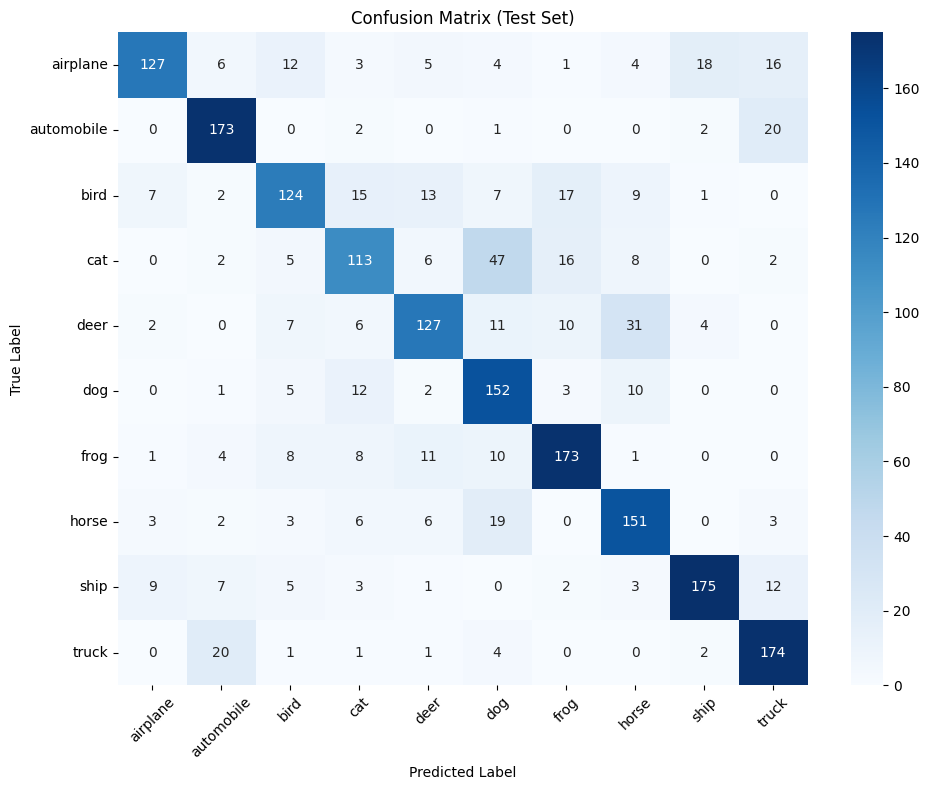

In [86]:
# Confusion Matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [87]:
# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

    airplane       0.85      0.65      0.74       196
  automobile       0.80      0.87      0.83       198
        bird       0.73      0.64      0.68       195
         cat       0.67      0.57      0.61       199
        deer       0.74      0.64      0.69       198
         dog       0.60      0.82      0.69       185
        frog       0.78      0.80      0.79       216
       horse       0.70      0.78      0.74       193
        ship       0.87      0.81      0.84       217
       truck       0.77      0.86      0.81       203

    accuracy                           0.74      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.75      0.74      0.74      2000



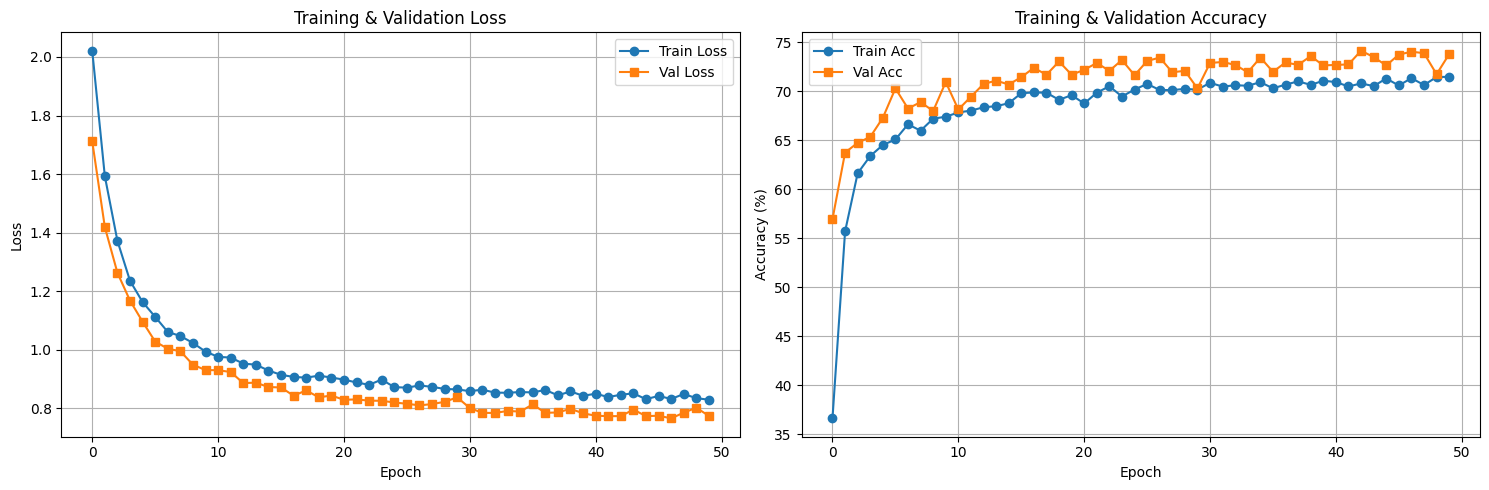

In [92]:
# Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='s')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Acc', marker='o')
ax2.plot(val_accuracies, label='Val Acc', marker='s')
ax2.set_title('Training & Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [120]:
# Per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1) * 100
print(f"\nPer-class Test Accuracy:")
for i, (cls, acc) in enumerate(zip(class_names, class_acc)):
    print(f"  {cls:12s}: {acc:6.2f}%")
print(f"\nOverall Test Accuracy: {test_acc:.2f}%")

# Top-5 Accuracy (bonus metric for GoogLeNet)
top5_correct = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, top5 = outputs.topk(5, 1, True, True)
        top5_correct += torch.sum((top5 == labels.unsqueeze(1))).item()





Per-class Test Accuracy:
  airplane    :  64.80%
  automobile  :  87.37%
  bird        :  63.59%
  cat         :  56.78%
  deer        :  64.14%
  dog         :  82.16%
  frog        :  80.09%
  horse       :  78.24%
  ship        :  80.65%
  truck       :  85.71%

Overall Test Accuracy: 74.45%


In [96]:
from google.colab import files
uploaded = files.upload()

Saving 4.jpg to 4 (1).jpg
Saving 3.jpg to 3 (1).jpg
Saving 2.jpg to 2 (1).jpg
Saving 1.jpg to 1 (1).jpg


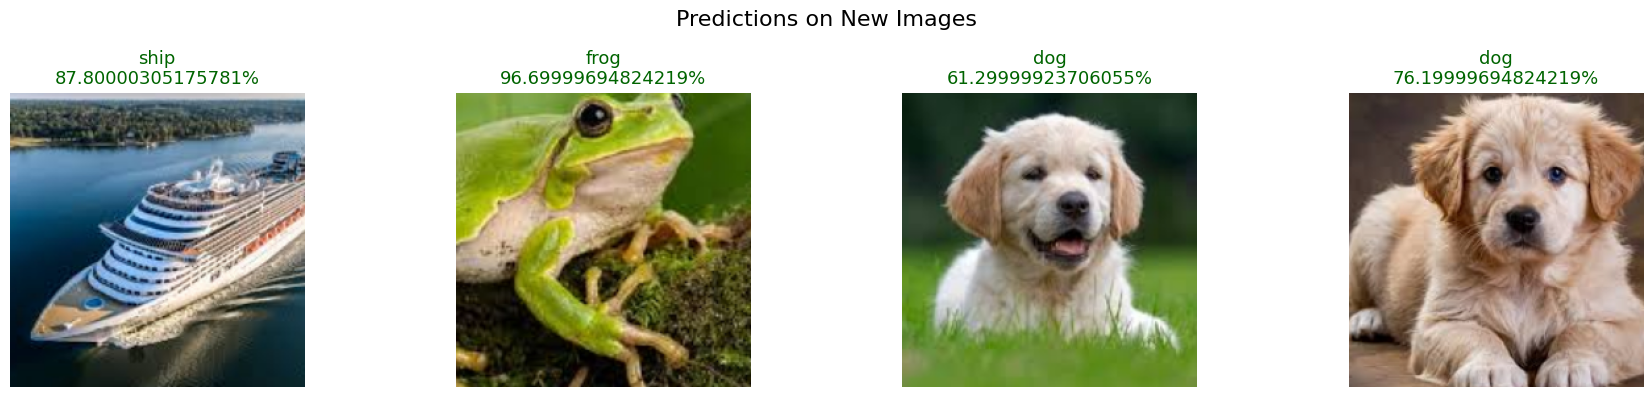

PREDICTIONS
4 (1).jpg            → ship       (87.8%)
3 (1).jpg            → frog       (96.7%)
2 (1).jpg            → dog        (61.3%)
1 (1).jpg            → dog        (76.2%)


In [111]:
import os
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image_paths = list(uploaded.keys())

custom_tensors = []
for path in image_paths:
    img = Image.open(path).convert('RGB')
    tensor = custom_transform(img)
    custom_tensors.append(tensor)

batch = torch.stack(custom_tensors).to(device)

model.eval()
with torch.no_grad():
    logits = model(batch)
    probs = F.softmax(logits, dim=1)
    conf, pred = torch.max(probs, dim=1)
    conf = (conf.cpu().numpy() * 100).round(1)
    pred_idx = pred.cpu().numpy()

def denorm(t):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = t.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i in range(4):
    img_np = denorm(batch[i])
    pred_label = class_names[pred_idx[i]]
    c = conf[i]
    axes[i].imshow(img_np)
    axes[i].set_title(f"{pred_label}\n{c}%", fontsize=13, color='darkgreen')
    axes[i].axis('off')

plt.suptitle("Predictions on New Images", fontsize=16)
plt.tight_layout()
plt.show()

print("PREDICTIONS")
for i, path in enumerate(image_paths):
    print(f"{os.path.basename(path):20s} → {class_names[pred_idx[i]]:10s} ({conf[i]:.1f}%)")

In [91]:
# !mlflow ui


[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
INFO:     Started parent process [61318]
INFO:     Started server process [61323]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started server process [61322]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started server process [61320]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started server process [61321]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Shutting down
INFO:     Shutting down
INFO:     Shutting down
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Waiting for application shutdown.
INFO:     Ap